In [1]:
#import cupy as cp
import scrublet as scr
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy


def MovePlots(plotpattern, subplotdir):
    os.system('mkdir -p '+str(sc.settings.figdir)+'/'+subplotdir)
    os.system('mv '+str(sc.settings.figdir)+'/*'+plotpattern+'** '+str(sc.settings.figdir)+'/'+subplotdir)


sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.figdir = './figures/preprocessing/'
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80)  # low dpi (dots per inch) yields small inline figures

sys.executable

-----
anndata     0.10.8
scanpy      1.10.3
-----
PIL                 10.4.0
asttokens           NA
backports           NA
cffi                1.17.1
colorama            0.4.6
comm                0.2.2
cycler              0.12.1
cython_runtime      NA
dateutil            2.9.0.post0
debugpy             1.8.8
decorator           5.1.1
dill                0.3.9
exceptiongroup      1.2.2
executing           2.1.0
h5py                3.12.1
igraph              0.11.8
ipykernel           6.29.5
jaraco              NA
jedi                0.19.2
joblib              1.4.2
kiwisolver          1.4.7
legacy_api_wrap     NA
leidenalg           0.10.2
llvmlite            0.43.0
louvain             0.8.2
matplotlib          3.6.3
more_itertools      10.3.0
mpl_toolkits        NA
natsort             8.4.0
nt                  NA
numba               0.60.0
numpy               1.26.4
packaging           24.2
pandas              2.2.3
parso               0.8.4
pkg_resources       NA
platformdirs        4

'G:\\Miniconda3\\envs\\omicverse\\python.exe'

# Detect doublet

In [2]:
# Benjamini-Hochberg and Bonferroni FDR helper functions.

def bh(pvalues):
    """
    Computes the Benjamini-Hochberg FDR correction.
    
    Input:
        * pvals - vector of p-values to correct
    """
    pvalues = np.array(pvalues)
    n = int(pvalues.shape[0])
    new_pvalues = np.empty(n)
    values = [ (pvalue, i) for i, pvalue in enumerate(pvalues) ]
    values.sort()
    values.reverse()
    new_values = []
    for i, vals in enumerate(values):
        rank = n - i
        pvalue, index = vals
        new_values.append((n/rank) * pvalue)
    for i in range(0, int(n)-1):
        if new_values[i] < new_values[i+1]:
            new_values[i+1] = new_values[i]
    for i, vals in enumerate(values):
        pvalue, index = vals
        new_pvalues[index] = new_values[i]
    return new_pvalues

def bonf(pvalues):
    """
    Computes the Bonferroni FDR correction.
    
    Input:
        * pvals - vector of p-values to correct
    """
    new_pvalues = np.array(pvalues) * len(pvalues)
    new_pvalues[new_pvalues>1] = 1
    return new_pvalues

Scrumblet
(Courtesy of K Polansky)

Two-step doublet score processing, mirroring the approach from Popescu et al. https://www.nature.com/articles/s41586-019-1652-y which was closely based on Pijuan-Sala et al. https://www.nature.com/articles/s41586-019-0933-9

The first step starts with some sort of doublet score, e.g. Scrublet, and ends up with a per-cell p-value (with significant values marking doublets). For each sample individually:

run Scrublet to obtain each cell's score
overcluster the manifold - run a basic Scanpy pipeline up to clustering, then additionally cluster each cluster separately
compute per-cluster Scrublet scores as the median of the observed values, and use those going forward
identify p-values:
compute normal distribution parameters: centered at the median of the scores, with a MAD-derived standard deviation
the score distribution is zero-truncated, so as per the paper I only use above-median values to compute the MAD
K deviates from the paper a bit, at least the exact wording captured within it, and multiply the MAD by 1.4826 to obtain a literature-derived normal distribution standard deviation estimate
FDR-correct the p-values via Benjamini-Hochberg
write out all this doublet info into CSVs for later use
NOTE: The second step is performed later, in a multi-sample space

In [3]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)

In [5]:
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset
sample,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house


In [6]:
meta['sample'] = meta['sample_id'].astype('str')
plotmeta = list(meta.columns)
plotmeta.append('sample')
print('Number of sample: ', meta.index.size)
meta

Number of sample:  15


,sample_id,donor,gw,gender,10xKit,sequencing,dataset,sample
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public,gw9
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public,gw11
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house,gw14
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public,gw15
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house,gw16
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house,gw17_1
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house,gw17_2
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public,gw17_3
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house,gw18


In [7]:
samples = meta.index.to_list()
samples

['9.5gw',
 '11.2gw',
 '14+3gw',
 '15gw',
 '16+4gw',
 '17+2gw',
 '17+3gw',
 '17gw',
 '18+3gw',
 '20gw',
 '22+2gw_1',
 '22+2gw_2',
 '23+2gw',
 '25+6gw',
 '26+3gw']

In [8]:
meta['sample']

sample
9.5gw          gw9
11.2gw        gw11
14+3gw        gw14
15gw          gw15
16+4gw        gw16
17+2gw      gw17_1
17+3gw      gw17_2
17gw        gw17_3
18+3gw        gw18
20gw          gw20
22+2gw_1    gw22_1
22+2gw_2    gw22_2
23+2gw        gw23
25+6gw        gw25
26+3gw        gw26
Name: sample, dtype: object

In [23]:
#there's loads of clustering going on, so set verbosity low unless you enjoy walls of text
sc.settings.verbosity = 0  # verbosity: errors (0), warnings (1), info (2), hints (3)

scorenames = ['scrublet_score','scrublet_cluster_score','zscore','bh_pval','bonf_pval']
if not os.path.exists('scrublet-scores'):
    os.makedirs('scrublet-scores')
    #loop over the subfolders of the rawdata folder

samples = meta.index.to_list()

for sample in reversed(list(samples)):
    print(sample)
    #import data
    adata_sample = sc.read(data_dir+sample+'/human_gw_raw.h5ad',cache=True)
    adata_sample.var_names_make_unique()
    #rename cells to SAMPLE_BARCODE
    adata_sample.obs_names = [sample+'_'+i for i in adata_sample.obs_names]
    #do some early filtering to retain meaningful cells for doublet inspection
    sc.pp.filter_cells(adata_sample, min_genes=200)
    sc.pp.filter_genes(adata_sample, min_cells=3)
    #convert to lower to be species agnostic: human mito start with MT-, mouse with mt-
    mito_genes = [name for name in adata_sample.var_names if name.lower().startswith('MT-')]
    # for each cell compute fraction of counts in mito genes vs. all genes
    # the `.A1` is only necessary as X is sparse (to transform to a dense array after summing)
    adata_sample.obs['percent_mito'] = np.sum(
        adata_sample[:, mito_genes].X, axis=1).A1 / np.sum(adata_sample.X, axis=1).A1
    adata_sample = adata_sample[adata_sample.obs['percent_mito'] < 0.5, :]

    #set up and run Scrublet, seeding for replicability
    np.random.seed(0)
    scrub = scr.Scrublet(adata_sample.X)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(verbose=False)
    adata_sample.obs['scrublet_score'] = doublet_scores

    #overcluster prep. run turbo basic scanpy pipeline
    sc.pp.normalize_per_cell(adata_sample, counts_per_cell_after=1e4)
    sc.pp.log1p(adata_sample)
    sc.pp.highly_variable_genes(adata_sample, min_mean=0.0125, max_mean=3, min_disp=0.5)
    adata_sample = adata_sample[:, adata_sample.var['highly_variable']]
    sc.pp.scale(adata_sample, max_value=10)
    sc.tl.pca(adata_sample, svd_solver='arpack')
    sc.pp.neighbors(adata_sample)
    #overclustering proper - do basic clustering first, then cluster each cluster
    sc.tl.leiden(adata_sample)
    adata_sample.obs['leiden'] = [str(i) for i in adata_sample.obs['leiden']]
    for clus in np.unique(adata_sample.obs['leiden']):
        adata_sub = adata_sample[adata_sample.obs['leiden']==clus].copy()
        sc.tl.leiden(adata_sub)
        adata_sub.obs['leiden'] = [clus+','+i for i in adata_sub.obs['leiden']]
        adata_sample.obs.loc[adata_sub.obs_names,'leiden'] = adata_sub.obs['leiden']

    #compute the cluster scores - the median of Scrublet scores per overclustered cluster
    for clus in np.unique(adata_sample.obs['leiden']):
        adata_sample.obs.loc[adata_sample.obs['leiden']==clus, 'scrublet_cluster_score'] = \
            np.median(adata_sample.obs.loc[adata_sample.obs['leiden']==clus, 'scrublet_score'])
    #now compute doublet p-values. figure out the median and mad (from above-median values) for the distribution
    med = np.median(adata_sample.obs['scrublet_cluster_score'])
    mask = adata_sample.obs['scrublet_cluster_score']>med
    mad = np.median(adata_sample.obs['scrublet_cluster_score'][mask]-med)
    #let's do a one-sided test. the Bertie write-up does not address this but it makes sense
    zscores = (adata_sample.obs['scrublet_cluster_score'].values - med) / (1.4826 * mad)
    adata_sample.obs['zscore'] = zscores
    pvals = 1-scipy.stats.norm.cdf(zscores)
    adata_sample.obs['bh_pval'] = bh(pvals)
    adata_sample.obs['bonf_pval'] = bonf(pvals)

    #create results data frame for single sample and copy stuff over from the adata object
    scrublet_sample = pd.DataFrame(0, index=adata_sample.obs_names, columns=scorenames)
    for score in scorenames:
        scrublet_sample[score] = adata_sample.obs[score]
    #write out complete sample scores
    scrublet_sample.to_csv('scrublet-scores/'+sample+'.csv')

26+3gw


G:\Miniconda3\envs\omicverse\lib\site-packages\scrublet\helper_functions.py:252: RuntimeWarning: invalid value encountered in sqrt
  CV_input = np.sqrt(b);
C:\Users\Dell\AppData\Local\Temp\ipykernel_26136\872420463.py:33: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sample.obs['scrublet_score'] = doublet_scores
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


25+6gw


G:\Miniconda3\envs\omicverse\lib\site-packages\scrublet\helper_functions.py:239: RuntimeWarning: invalid value encountered in log
  gLog = lambda input: np.log(input[1] * np.exp(-input[0]) + input[2])
G:\Miniconda3\envs\omicverse\lib\site-packages\scrublet\helper_functions.py:252: RuntimeWarning: invalid value encountered in sqrt
  CV_input = np.sqrt(b);
C:\Users\Dell\AppData\Local\Temp\ipykernel_26136\872420463.py:33: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sample.obs['scrublet_score'] = doublet_scores
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


23+2gw


...

G:\Miniconda3\envs\omicverse\lib\site-packages\scrublet\helper_functions.py:239: RuntimeWarning: invalid value encountered in log
  gLog = lambda input: np.log(input[1] * np.exp(-input[0]) + input[2])
G:\Miniconda3\envs\omicverse\lib\site-packages\scrublet\helper_functions.py:252: RuntimeWarning: invalid value encountered in sqrt
  CV_input = np.sqrt(b);
C:\Users\Dell\AppData\Local\Temp\ipykernel_26136\872420463.py:33: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sample.obs['scrublet_score'] = doublet_scores
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


11.2gw


G:\Miniconda3\envs\omicverse\lib\site-packages\scrublet\helper_functions.py:239: RuntimeWarning: invalid value encountered in log
  gLog = lambda input: np.log(input[1] * np.exp(-input[0]) + input[2])
G:\Miniconda3\envs\omicverse\lib\site-packages\scrublet\helper_functions.py:252: RuntimeWarning: invalid value encountered in sqrt
  CV_input = np.sqrt(b);
C:\Users\Dell\AppData\Local\Temp\ipykernel_26136\872420463.py:33: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sample.obs['scrublet_score'] = doublet_scores
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


9.5gw


G:\Miniconda3\envs\omicverse\lib\site-packages\scrublet\helper_functions.py:239: RuntimeWarning: invalid value encountered in log
  gLog = lambda input: np.log(input[1] * np.exp(-input[0]) + input[2])
G:\Miniconda3\envs\omicverse\lib\site-packages\scrublet\helper_functions.py:252: RuntimeWarning: invalid value encountered in sqrt
  CV_input = np.sqrt(b);
C:\Users\Dell\AppData\Local\Temp\ipykernel_26136\872420463.py:33: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sample.obs['scrublet_score'] = doublet_scores
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


### Preprocessing


Load 10x
Filter: 1) cells (< 10 genes); 2) genes (< 3 cells)

Quantify: 1) % mitochondrial genes; 2) total counts

In [24]:
adata_sample

AnnData object with n_obs × n_vars = 4284 × 4166
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'percent_mito', 'scrublet_score', 'n_counts', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval'
    var: 'gene_ids', 'feature_types', 'Gene', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_cells', 'mean', 'std'
    uns: 'cell_type_colors', 'dendrogram_cell_type', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'louvain', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [25]:
holder = []
for sample in meta.index:
    print(sample)
    # Load 10x data as AnnData
    #adata_sample = sc.read_10x_mtx(data_dir+'rawdata_pbx3_neo/'+sample+'/outs/filtered_feature_bc_matrix/',cache=True)
    holder.append(sc.read(data_dir+sample+'/human_gw_raw.h5ad',cache=True)) 
    # Set names of observation as sample + _ + barcode/probe
    holder[-1].obs_names = [sample+'_'+i.split('-')[0] for i in holder[-1].obs_names]
    # Filer genes expressed in less than 3 cells
    sc.pp.filter_genes(holder[-1], min_cells=3)
    # Filer cells with less than 10 genes expressed
    sc.pp.filter_cells(holder[-1], min_genes=10)
    # add in metadata
    holder[-1].obs['sample'] = sample
    for val in meta.columns:
        holder[-1].obs[val] = meta[val][sample]
    # Extract mitochondial genes
    mito_genes = [name for name in holder[-1].var_names if name.startswith('MT-')]
    #for each cell compute fraction of counts in mito genes vs. all genes
    #the `.A1` is only necessary, as X is sparse - it transform to a dense array after summing
    holder[-1].obs['percent_mito'] = np.sum(
        holder[-1][:, mito_genes].X, axis=1).A1 / np.sum(holder[-1].X, axis=1).A1
    #add the total counts per cell as observations-annotation to adata
    holder[-1].obs['n_counts'] = holder[-1].X.sum(axis=1).A1
    print('Total number of cells: {:d}'.format(holder[-1].n_obs))
    print('Total number of genes: {:d}'.format(holder[-1].n_vars))

9.5gw
Total number of cells: 4284
Total number of genes: 22512
11.2gw
Total number of cells: 4051
Total number of genes: 26703
14+3gw
Total number of cells: 12081
Total number of genes: 29961
15gw
Total number of cells: 2146
Total number of genes: 18995
16+4gw
Total number of cells: 8708
Total number of genes: 29950
17+2gw
Total number of cells: 6773
Total number of genes: 26118
17+3gw
Total number of cells: 7148
Total number of genes: 26633
17gw
Total number of cells: 4538
Total number of genes: 19729
18+3gw
Total number of cells: 9595
Total number of genes: 26884
20gw
Total number of cells: 3833
Total number of genes: 26808
22+2gw_1
Total number of cells: 5837
Total number of genes: 28742
22+2gw_2
Total number of cells: 7861
Total number of genes: 26226
23+2gw
Total number of cells: 3597
Total number of genes: 24258
25+6gw
Total number of cells: 13936
Total number of genes: 28576
26+3gw
Total number of cells: 7872
Total number of genes: 25874


In [26]:
# confirm N samples
print(len(holder))
# merge datasets
adata = holder[0].concatenate(holder[1:],join='outer',index_unique=None)
# copy of this matrix in Compressed Sparse Row format
adata.X = adata.X.tocsr()
adata

15


C:\Users\Dell\AppData\Local\Temp\ipykernel_26136\1688759299.py:4: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = holder[0].concatenate(holder[1:],join='outer',index_unique=None)


AnnData object with n_obs × n_vars = 102260 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'mt-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'mt-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'Gene-10', 'mt-10', 'n_cells_by_counts-10', 'mean_counts-10', 'pct_dropout_by_counts-10', 'total_counts-10', 'highly_variable-10', 'means-10', 'dispersions-10', 'disp

In [13]:
adata.write('all_rawcounts.h5ad')

TypeError: Can't implicitly convert non-string objects to strings

QC pplots
Plot distributions of the values n_genes, n_counts and percent_mito

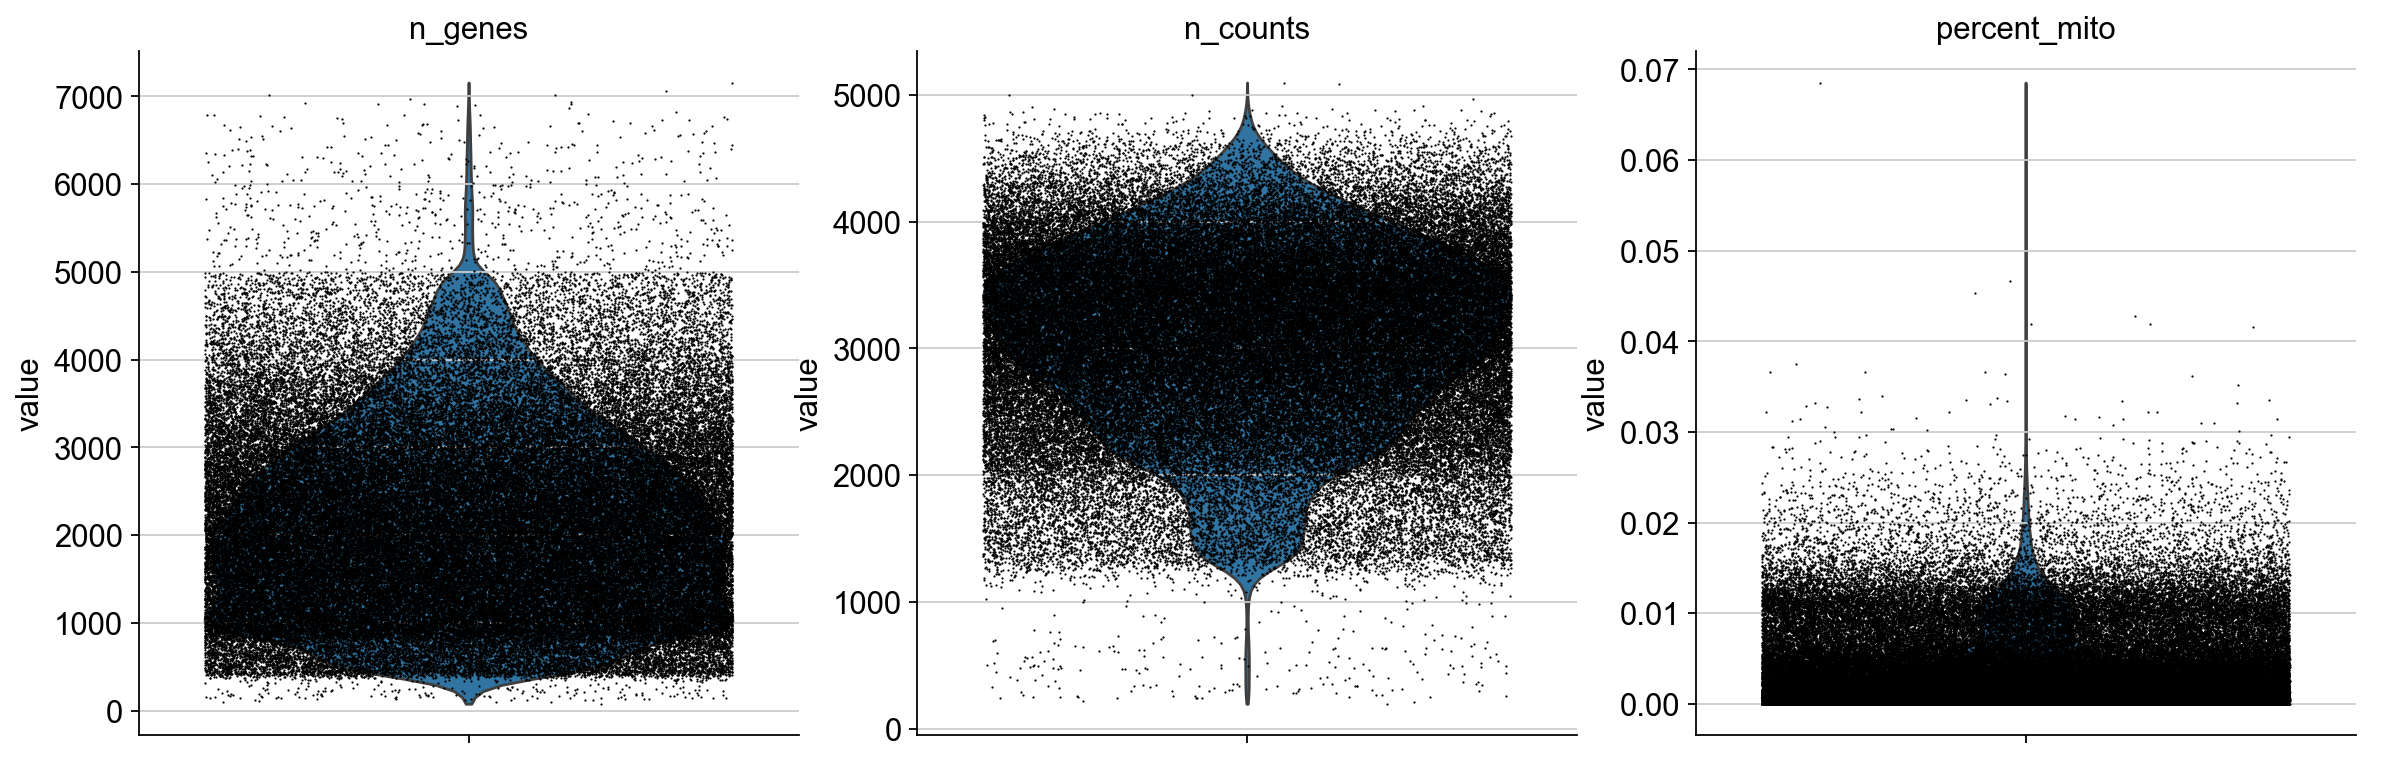

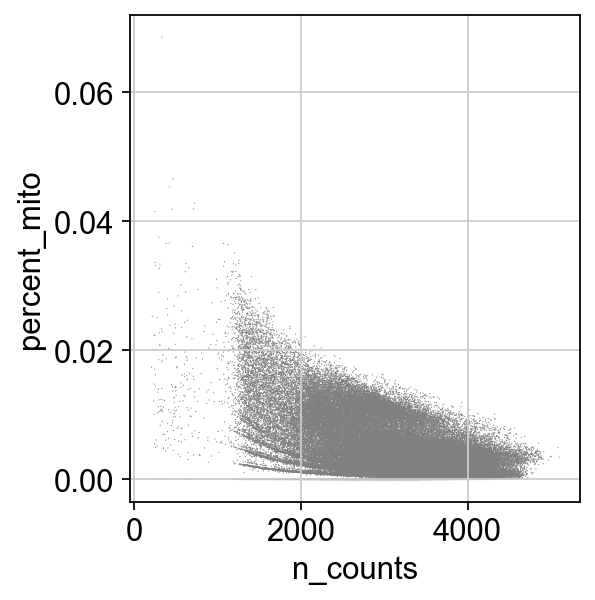

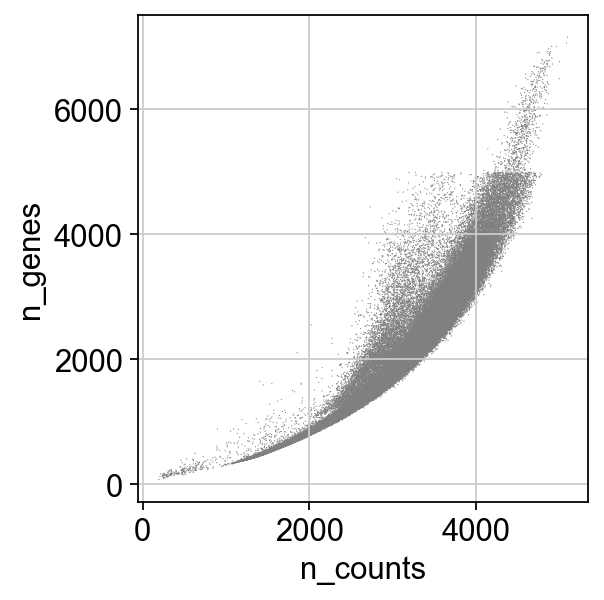

In [14]:
sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mito'],jitter=0.4, multi_panel=True, save='.pdf', show=True)
sc.pl.scatter(adata, x='n_counts', y='percent_mito', save='_numi_vs_mito.pdf', show=True)
sc.pl.scatter(adata, x='n_counts', y='n_genes', save='_numi_vs_ngenes.pdf', show=True)

In [15]:
sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mito'], groupby='sample', rotation = 90, jitter=0.4, save='_batch_collection.pdf', show=False)

[<Axes: ylabel='n_genes'>,
 <Axes: ylabel='n_counts'>,
 <Axes: ylabel='percent_mito'>]

In [16]:
print('Total number of cells: {:d}'.format(adata.n_obs))
print('Total number of genes: {:d}'.format(adata.n_vars))
pd.DataFrame(adata.obs).to_csv(str(sc.settings.figdir)+'/metadata_prefilters.csv')

Total number of cells: 102260
Total number of genes: 46922


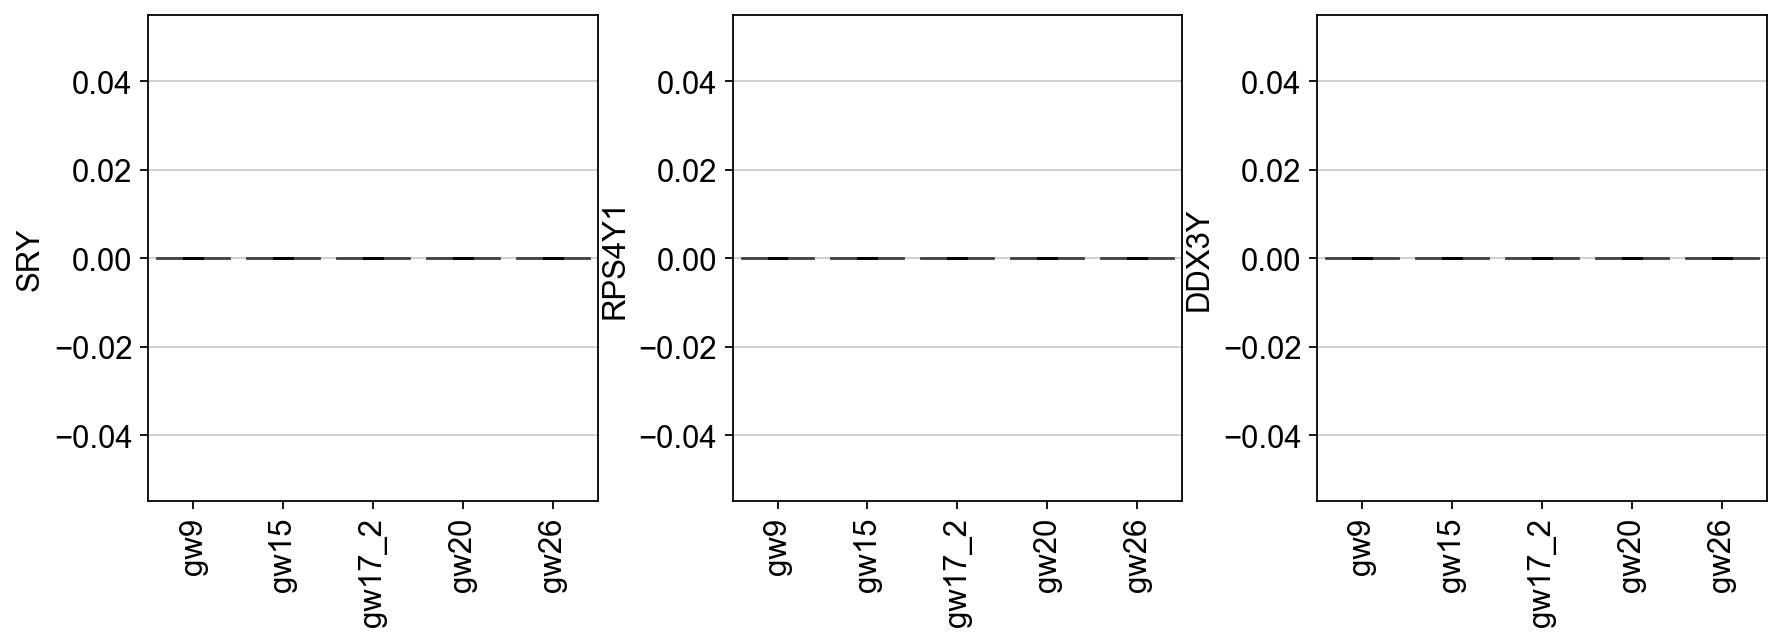

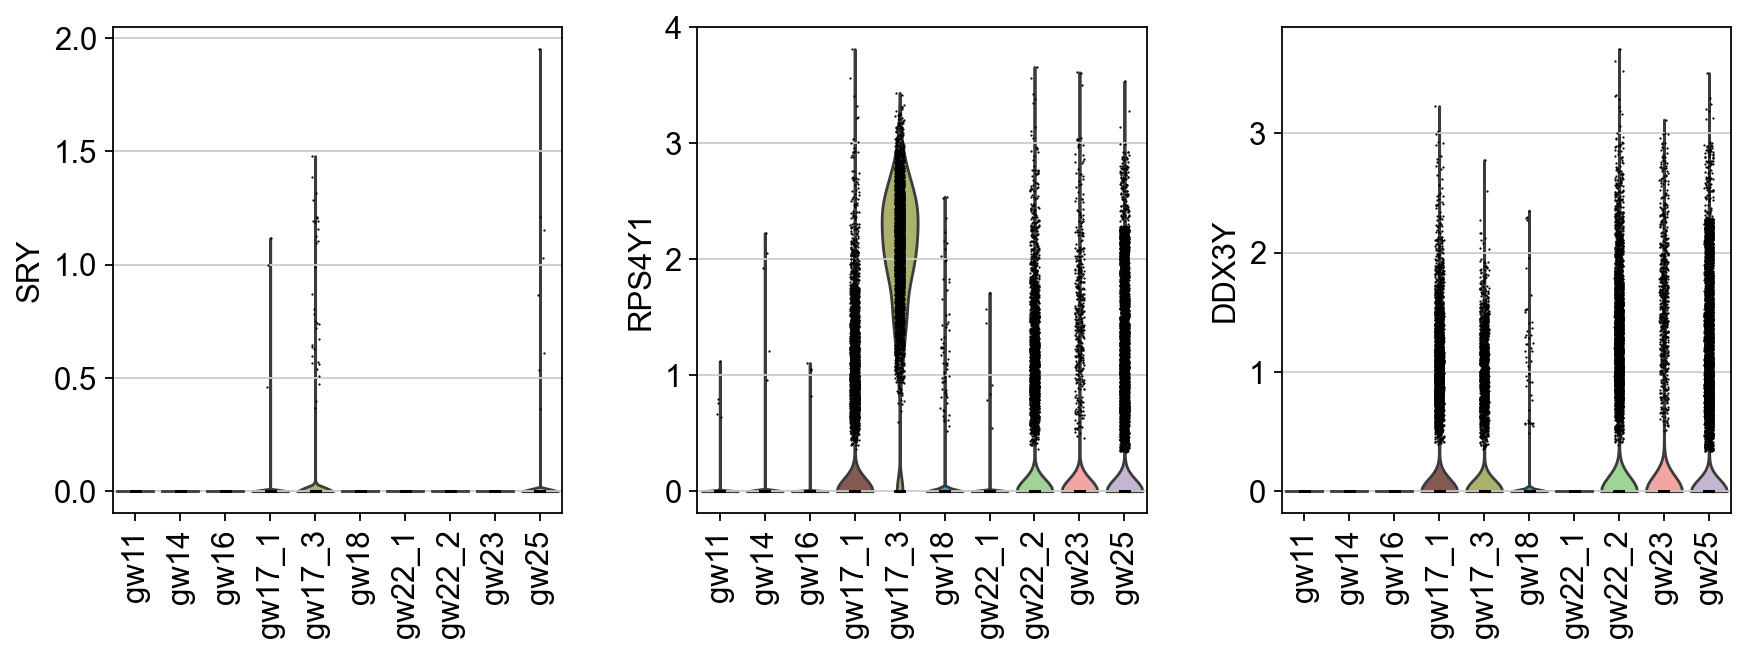

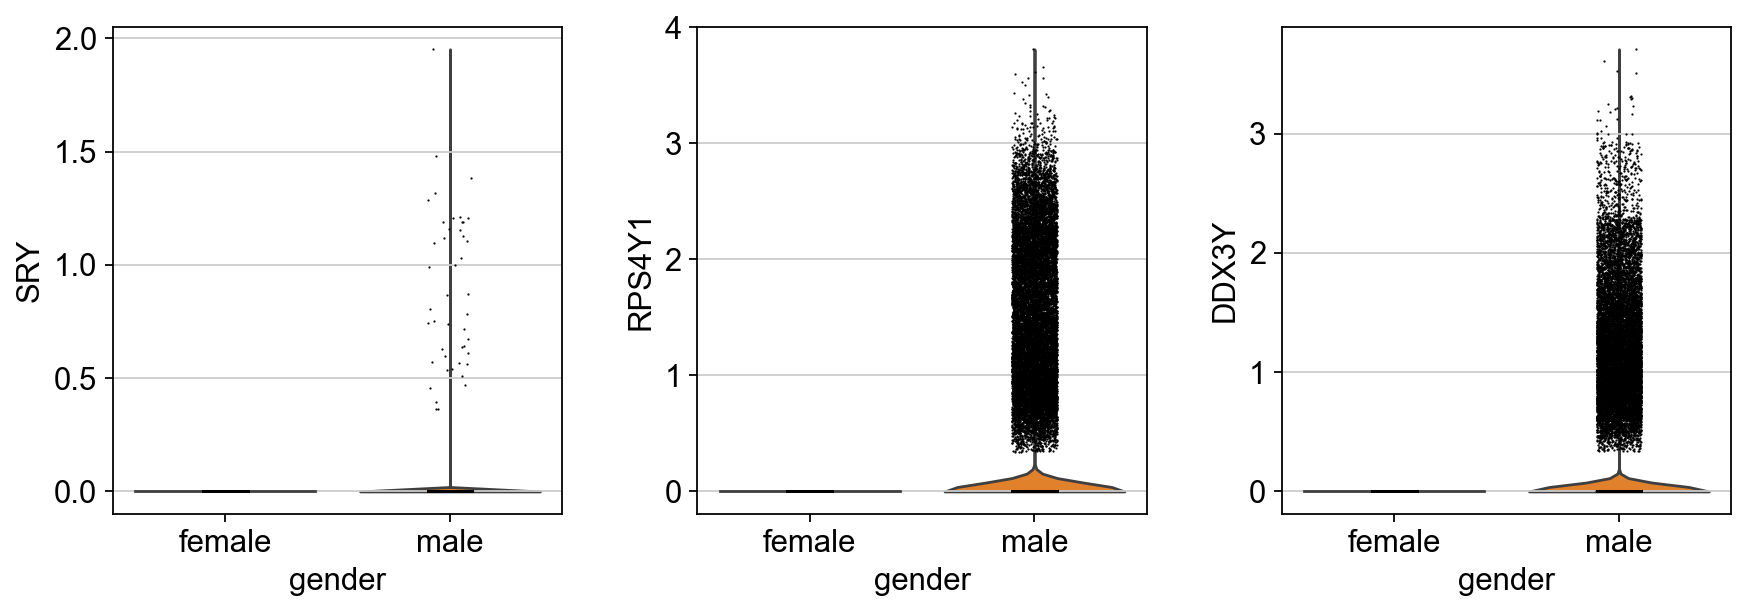

In [18]:
sc.pl.violin(adata[[ i == 'female' for i in adata.obs.gender]], ['SRY', 'RPS4Y1','DDX3Y'], groupby='sample', rotation = 90,save="_human_cochlea_male3.pdf",) # FEMALE
sc.pl.violin(adata[[ i == 'male' for i in adata.obs.gender]], ['SRY', 'RPS4Y1','DDX3Y'], groupby='sample', rotation = 90,save="_human_cochlea_male_2.pdf",) # MALE
sc.pl.violin(adata, ['SRY', 'RPS4Y1','DDX3Y'], groupby='gender',save="_human_cochlea_male.pdf",) # MALE

In [19]:
adata

AnnData object with n_obs × n_vars = 102260 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'mt-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'mt-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'Gene-10', 'mt-10', 'n_cells_by_counts-10', 'mean_counts-10', 'pct_dropout_by_counts-10', 'total_counts-10', 'highly_variable-10', 'means-10', 'dispersions-10', 'disp

Filter cells with few genes 
Check number of genes per cell distribution and filter cells accordingly

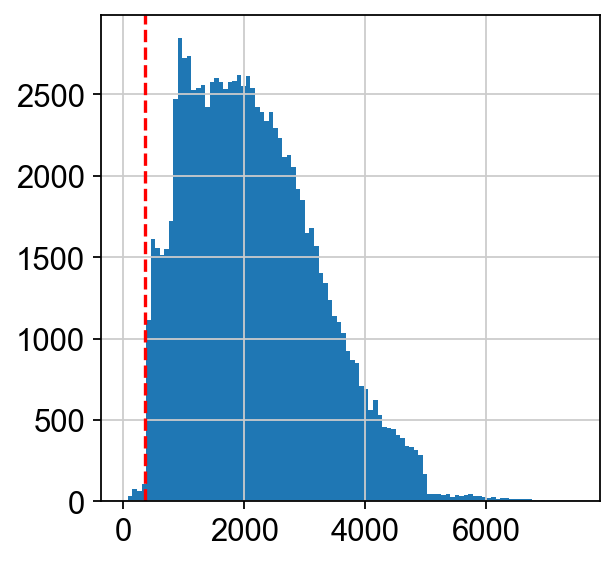

In [28]:
plt.hist(adata.obs['n_genes'], bins = 100,range=(0,7500))
plt.axvline(350, linestyle = '--', color = 'red')

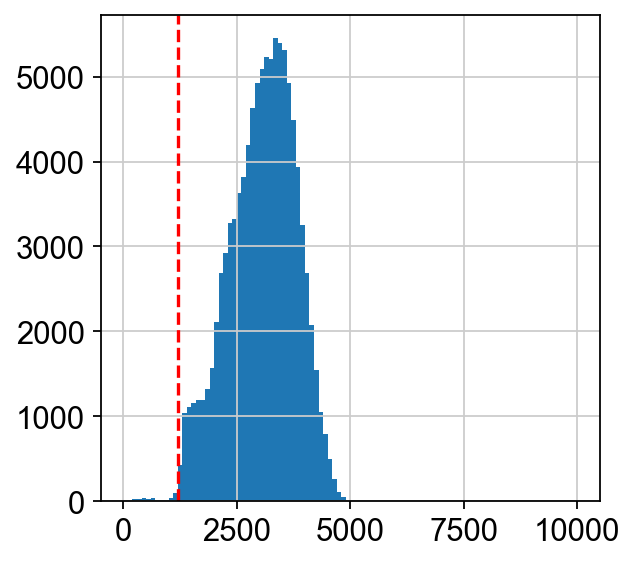

In [29]:
plt.hist(adata.obs['n_counts'], bins = 100,range=(0,10000))
plt.axvline(1200, linestyle = '--', color = 'red')

In [22]:
# confirm N samples
print(len(holder))
# merge datasets
adata = holder[0].concatenate(holder[1:],join='inner',index_unique=None)
# copy of this matrix in Compressed Sparse Row format
adata.X = adata.X.tocsr()
adata

15


C:\Users\Dell\AppData\Local\Temp\ipykernel_26136\3147036400.py:4: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = holder[0].concatenate(holder[1:],join='inner',index_unique=None)


AnnData object with n_obs × n_vars = 102260 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'n_cells_by_counts-10', 'mean_counts-10', 'pct_dropout_by_counts-10', 'total_counts-10', 'highly_variable-10', 'means-10', 'dispersions-10', 'dispersions_norm-10', 'n_cells-10', 'genome-10

In [30]:
adata_qc = adata.copy()
# Filter raw cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata_qc.n_obs))

np.quantile(adata.obs['n_counts'], [.99])
sc.pp.filter_cells(adata_qc, min_counts = 1200)
print('Number of cells after min count filter: {:d}'.format(adata_qc.n_obs))

sc.pp.filter_cells(adata_qc, max_counts = 10000)
print('Number of cells after max count filter: {:d}'.format(adata_qc.n_obs))

np.quantile(adata.obs['n_genes'], [.99])
sc.pp.filter_cells(adata_qc, min_genes = 350)
print('Number of cells after min genes filter: {:d}'.format(adata_qc.n_obs))

sc.pp.filter_cells(adata_qc, max_genes = 7500)
print('Number of cells after max genes filter: {:d}'.format(adata_qc.n_obs))

#adata_qc = adata_qc[adata_qc.obs['percent_mito'] < 0.1]
#print('Number of cells after mito filter: {:d}'.format(adata_qc.n_obs))

Total number of cells: 102260
Number of cells after min count filter: 101897
Number of cells after max count filter: 101897
Number of cells after min genes filter: 101897
Number of cells after max genes filter: 101897


In [31]:
print('Total number of cells: {:d}'.format(adata_qc.n_obs))
print('Total number of genes: {:d}'.format(adata_qc.n_vars))
adata_qc.obs['sample_id'].values.describe()

Total number of cells: 101897
Total number of genes: 46922


AttributeError: 'numpy.ndarray' object has no attribute 'describe'

Filter cells with large % mitochondrial genes

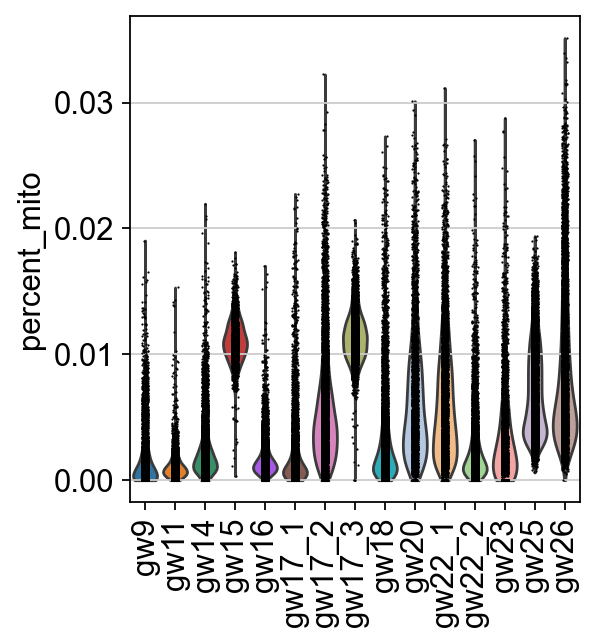

In [32]:
sc.pl.violin(adata_qc, ['percent_mito'], groupby='sample', rotation = 90) 

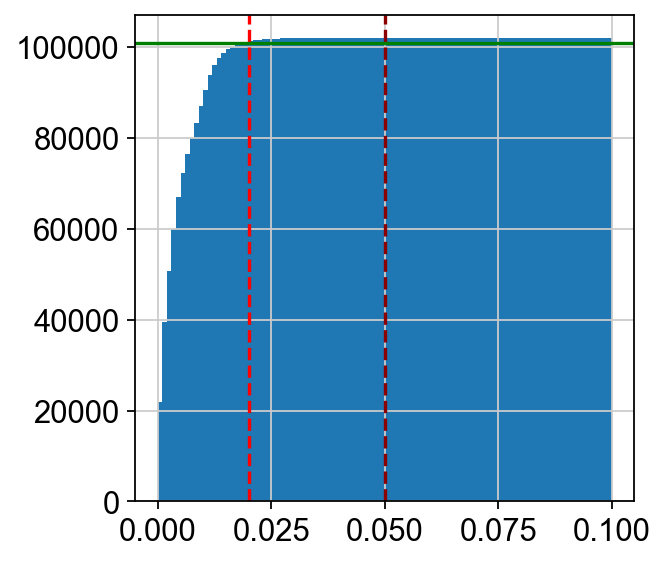

In [33]:
plt.hist(adata_qc.obs['percent_mito'], bins = 100, cumulative=True,range=(0,0.1))
plt.axvline(0.02, linestyle = '--', color = 'red')
plt.axvline(0.05, linestyle = '--', color = 'darkred')
plt.axhline(adata_qc.n_obs*0.99, linestyle = '-', color = 'green')

In [34]:
# >5%
adata_qc = adata_qc[adata_qc.obs['percent_mito'] < 0.05]
print('Number of cells after mito filter: {:d}'.format(adata_qc.n_obs))

Number of cells after mito filter: 101897


Remove cells with low counts high mito combo

In [35]:
x = [ int(i) < 1000 for i in adata_qc.obs['n_counts']]
adata_qc.obs['low_ncounts'] = [ str(i) for i in x ]

y = [ i > 0.1 for i in adata_qc.obs['percent_mito']]
adata_qc.obs['high_mito'] = [ str(i) for i in y ]

mask = [all(tup) for tup in zip(x,y)]
adata_qc.obs['low_ncounts_high_mito'] = [ str(i) for i in mask ]

adata_qc = adata_qc[[ 'False' in i for i in adata_qc.obs['low_ncounts_high_mito']   ]] 

C:\Users\Dell\AppData\Local\Temp\ipykernel_26136\3995539972.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_qc.obs['low_ncounts'] = [ str(i) for i in x ]


In [36]:
print('Total number of cells: {:d}'.format(adata_qc.n_obs))
print('Total number of genes: {:d}'.format(adata_qc.n_vars))
adata_qc.obs['sample'].values.describe()
pd.DataFrame(adata_qc.obs).to_csv(str(sc.settings.figdir)+'/metadata_filtered.csv')

Total number of cells: 101897
Total number of genes: 46922


In [37]:
adata_qc

View of AnnData object with n_obs × n_vars = 101897 × 46922
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito'
    var: 'gene_ids-0', 'feature_types-0', 'Gene-0', 'mt-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'Gene-1', 'mt-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'Gene-10', 'mt-10', 'n_cells_by_counts-10', 'mean_counts-10', 'pct_dropout_by_counts-10', 'total_counts-1

## Identify cells behaving like cc genes
#Per genes analysis: identify genes behaving like known cell cycle genes

In [253]:
bdata = adata_qc.copy()
# Normalize total counts per cell
sc.pp.normalize_per_cell(bdata, counts_per_cell_after=1e4)
# Logarithmize the data matrix
sc.pp.log1p(bdata)

In [254]:
# Extract highly variable genes
sc.pp.highly_variable_genes(bdata)
highly_variable_genes = bdata.var["highly_variable"]
bdata = bdata[:, highly_variable_genes]

In [255]:
# Traspose matrix for a GENE-centered analysis
bdata = bdata.copy().T

In [256]:
bdata.X.shape

(3194, 101419)

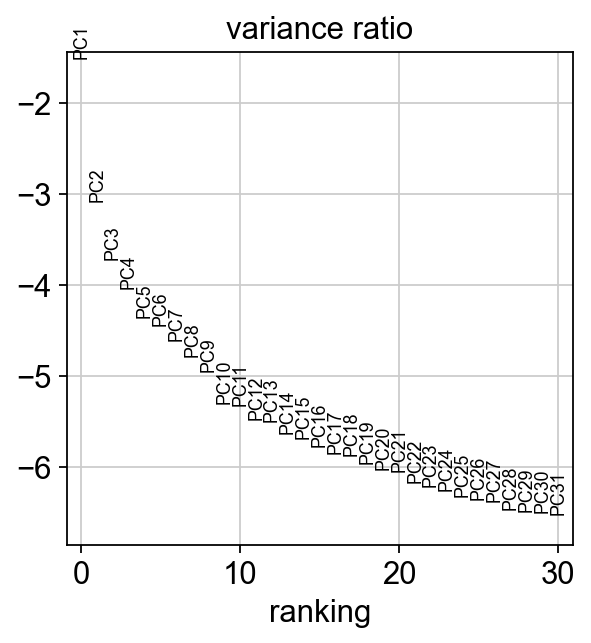

In [257]:
# Scale data to unit variance and zero mean
sc.pp.scale(bdata, max_value=10)

# Scatter plot in PCA coordinates
sc.tl.pca(bdata)
bdata.obsm['X_pca'] *= -1  # multiply by -1 to match Seurat
# Plot the variance ratio
sc.pl.pca_variance_ratio(bdata, log=True, save='_ccg_identification.pdf')

In [258]:
num_pcs = 10
# Compute a neighborhood graph of observations
sc.pp.neighbors(bdata, n_pcs=num_pcs)
# Embed the neighborhood graph using UMAP
sc.tl.umap(bdata)
# Cluster GENES into subgroups using louvain: resolution < 1 to find less clusters
sc.tl.leiden(bdata, resolution=1)

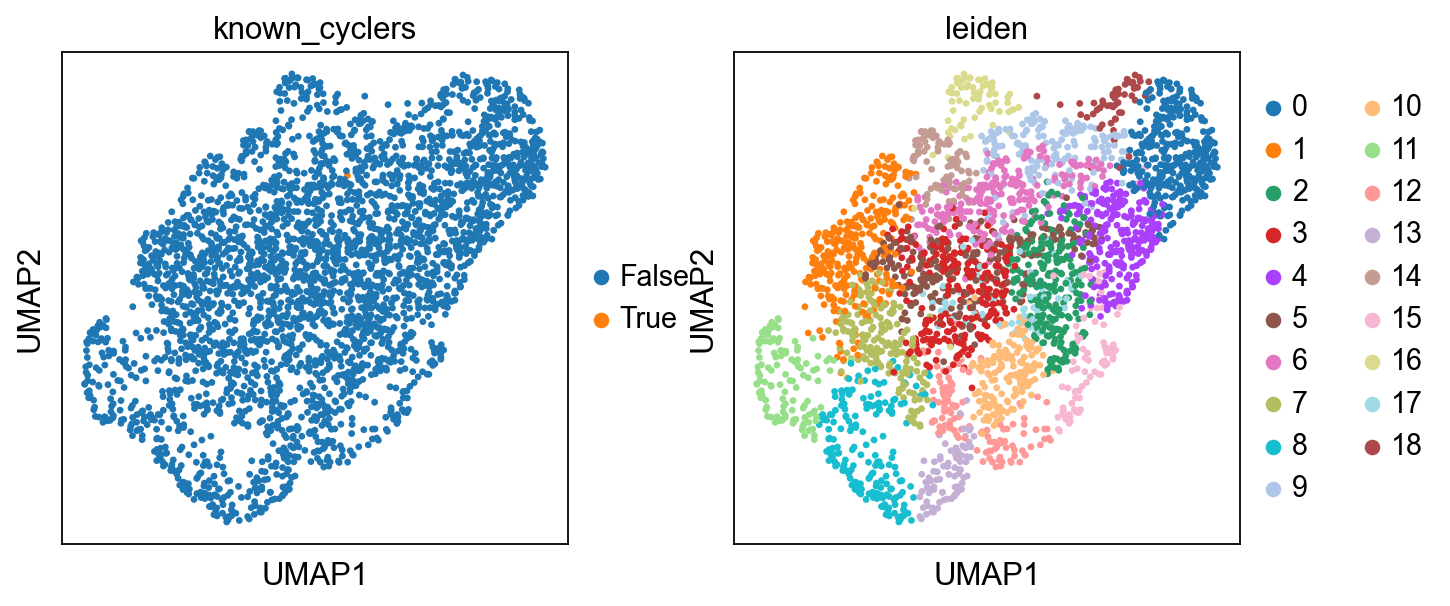

MKI67    6
Name: leiden, dtype: category
Categories (19, object): ['0', '1', '2', '3', ..., '15', '16', '17', '18']


In [259]:
# Locate ccs cluster
bdata.obs['known_cyclers'] = [i in ['CDK1','MKI67','CCNB2','PCNA'] for i in bdata.obs_names]
bdata.obs['known_cyclers'] = [ str(i) for i in  bdata.obs['known_cyclers']]
sc.pl.umap(bdata, color=['known_cyclers', 'leiden'], color_map='OrRd',save='_ccg_identification.pdf')
print(bdata.obs.loc[[i in ['CDK1','MKI67','CCNB2','PCNA'] for i in bdata.obs_names],'leiden'])

In [260]:
ccgs_cl = bdata.obs.loc['MKI67',['leiden']][0]
print("Cell cycle genes cluster is "+ccgs_cl)

Cell cycle genes cluster is 6


C:\Users\Dell\AppData\Local\Temp\ipykernel_60448\3086543397.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ccgs_cl = bdata.obs.loc['MKI67',['leiden']][0]


# Flag CYCLING GENES

In [261]:
# Add unstructured dict-like annotation for ccgs
adata_qc.uns['ccgs'] = list(bdata.obs[bdata.obs['leiden']==ccgs_cl].index)

C:\Users\Dell\AppData\Local\Temp\ipykernel_60448\1327359691.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata_qc.uns['ccgs'] = list(bdata.obs[bdata.obs['leiden']==ccgs_cl].index)


In [262]:
# Move plots
MovePlots('ccg_identification','ccg_identification')

# Score cell cycle

In [263]:
s_genes = [x.strip() for x in open('S_genes.tsv')]
g2m_genes = [x.strip() for x in open('G2M_genes.tsv')]

In [264]:
s_genes = [x for x in s_genes if x in adata_qc.var_names]
g2m_genes = [x for x in g2m_genes if x in adata_qc.var_names]

In [265]:
sc.tl.score_genes_cell_cycle(adata_qc, s_genes=s_genes, g2m_genes=g2m_genes)

# Identify HVGs Flavor='seurat_v3' expects count data.

## For more informations, see "Feature selection for individual datasets" at https://www.sciencedirect.com/science/article/pii/S0092867419305598

In [266]:
sc.pp.highly_variable_genes(adata_qc, flavor='seurat_v3', n_top_genes=2000, subset=False)

G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


# Load scrublet

In [267]:
scorenames = ['scrublet_score','scrublet_cluster_score','zscore','bh_pval','bonf_pval']

scrdf = []
for sample in meta.index:
    scrdf.append(pd.read_csv('scrublet-scores/'+sample+'.csv', header=0, index_col=0))
scrdf = pd.concat(scrdf)
scrdf.index = [i.replace('-1', '') for i in scrdf.index]

idx = [ i in adata_qc.obs_names for i in scrdf.index ]
scrdf = scrdf[idx]
for score in scorenames:
    adata_qc.obs[score] = scrdf[score]
adata_qc.obs['is_doublet'] = adata_qc.obs['bonf_pval'] < 0.01

In [268]:
adata_qc

AnnData object with n_obs × n_vars = 101419 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'n_cells_b

In [269]:
adata_qc.uns['ccgs']

['ACAP3',
 'SYTL1',
 'MATN1',
 'RHBDL2',
 'PTCH2',
 'AGBL4',
 'ELAVL4',
 'LRRC7',
 'TNNI3K',
 'PKN2-AS1',
 'PLPPR5',
 'OLFM3',
 'FMO5',
 'ASPM',
 'KIF14',
 'SYT2',
 'VASH2',
 'CENPF',
 'KCNK2',
 'SLC30A10',
 'CHRM3',
 'RRM2',
 'KIF3C',
 'RBKS',
 'ALK',
 'RMDN2-AS1',
 'CYP1B1',
 'ADD2',
 'THSD7B',
 'SCN3A',
 'ZNF804A',
 'TMEFF2',
 'CNTN6',
 'SUSD5',
 'LRTM1',
 'CADPS',
 'SYNPR',
 'ADAMTS9-AS1',
 'EPHA3',
 'COL8A1',
 'LINC00882',
 'TAGLN3',
 'GAP43',
 'STXBP5L',
 'TMEM108',
 'CLSTN2',
 'ZIC1',
 'P2RY14',
 'KCNMB2',
 'FGF12',
 'STK32B',
 'C1QTNF7',
 'KCTD8',
 'GABRA2',
 'GABRB1',
 'KIT',
 'CENPE',
 'ARHGEF38',
 'DKK2',
 'NDST4',
 'SYNPO2',
 'LINC01091',
 'PCDH18',
 'FREM3',
 'GYPE',
 'HHIP',
 'TLL1',
 'SPOCK3',
 'IRX2',
 'CDH9',
 'HAPLN1',
 'MEF2C-AS1',
 'CAMK4',
 'PRR16',
 'PRDM6',
 'SLC27A6',
 'TGFBI',
 'CDC25C',
 'FGF1',
 'KCNIP1',
 'COL23A1',
 'MYLK4',
 'MDGA1',
 'GCLC',
 'RIMS1',
 'SNAP91',
 'HS3ST5',
 'AGMO',
 'MEOX2',
 'TMEM196',
 'CPVL',
 'CHN2',
 'POU6F2',
 'HECW1',
 'ELN',
 'SRR

In [270]:
np.mean(adata_qc.obs['is_doublet'])

0.01949338881274712

In [271]:
np.mean(adata_qc.obs['scrublet_score']>0.3)

0.05733639653319398

In [272]:
adata_qc.raw = adata_qc.copy()

In [274]:
adata_qc.var

,Gene,mt,gene_ids-0,feature_types-0,n_cells_by_counts-0,mean_counts-0,pct_dropout_by_counts-0,total_counts-0,highly_variable-0,means-0,...,means-9,dispersions-9,dispersions_norm-9,n_cells-9,genome-9,highly_variable,highly_variable_rank,means,variances,variances_norm
LINC00115,LINC00115,False,ENSG00000225880,Gene Expression,21,0.002106,99.798928,22.0,False,0.005880,...,0.067178,1.554438,-0.494024,118,GRCh38,False,NaN,0.016367,0.020523,0.956335
SAMD11,SAMD11,False,ENSG00000187634,Gene Expression,432,0.048736,95.863654,509.0,False,0.129230,...,0.462321,2.188114,0.358019,416,GRCh38,True,1651.0,0.101127,0.148189,1.146654
NOC2L,NOC2L,False,ENSG00000188976,Gene Expression,776,0.083397,92.569897,871.0,False,0.218501,...,0.207575,1.757261,-0.147760,332,GRCh38,False,NaN,0.112169,0.131198,0.915564
KLHL17,KLHL17,False,ENSG00000187961,Gene Expression,135,0.013213,98.707392,138.0,False,0.042314,...,0.066774,1.956021,0.191566,88,GRCh38,False,NaN,0.019347,0.024987,0.986205
HES4,HES4,False,ENSG00000188290,Gene Expression,172,0.017714,98.353121,185.0,True,0.054790,...,0.301512,2.331965,0.833385,280,GRCh38,False,NaN,0.092666,0.131864,1.114440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND4L,MT-ND4L,True,ENSG00000212907,Gene Expression,823,0.110494,92.119877,1154.0,False,0.217154,...,1.153913,2.404651,0.287169,1298,GRCh38,True,809.0,0.453675,0.680531,1.256637
MT-ND4,MT-ND4,True,ENSG00000198886,Gene Expression,3058,1.172731,70.720031,12248.0,True,1.247012,...,2.221510,2.840447,-0.372193,2453,GRCh38,True,426.0,1.176966,1.579430,1.353665
MT-ND5,MT-ND5,True,ENSG00000198786,Gene Expression,1971,0.399368,81.127920,4171.0,True,0.630494,...,2.016688,2.844351,-0.152871,2157,GRCh38,True,419.0,0.913410,1.323758,1.357759
MT-ND6,MT-ND6,True,ENSG00000198695,Gene Expression,415,0.044427,96.026427,464.0,False,0.108814,...,0.585338,2.316790,0.806846,665,GRCh38,True,523.0,0.261513,0.430262,1.321075


In [275]:
adata_qc.obs_names_make_unique()
adata_qc.var_names_make_unique()

In [276]:
adata_qc

AnnData object with n_obs × n_vars = 101419 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'n_cells_b

In [277]:
adata_qc.write('all_rawcounts.h5ad')

# we do not remove cc genes as one cluster we named as cycling cell-type which highly expresses cell-cycling markers TOP2A,HMGB2 et al.

Normalize per cell and log transform After removing unwanted cells and genes from the dataset, the next step is to normalize the data. By default, we employ a global-scaling normalization method “LogNormalize” that normalizes the feature expression measurements for each cell by the total expression, multiplies this by a scale factor (10,000 by default), and log-transforms the result.

In [278]:
sc.pp.normalize_total(adata_qc, target_sum=1e4)
sc.pp.log1p(adata_qc)

# PCA

## 1. Filter HVGs in bdata and do PCA with them

In [279]:
bdata = adata_qc[:, adata_qc.var['highly_variable']]
print('Total number of cells: {:d}'.format(bdata.n_obs))
print('Total number of genes: {:d}'.format(bdata.n_vars))

Total number of cells: 101419
Total number of genes: 2000


In [280]:
sc.pp.scale(bdata, max_value=10)
sc.tl.pca(bdata, svd_solver='arpack', n_comps=50)

G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


## 2. Transfer PCA to the main adata

C:\Users\Dell\AppData\Local\Temp\ipykernel_60448\3332283898.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata_qc.var['highly_variable'].fillna(value=False, inplace=True) # fill NaNs with False so that subsetting to HVGs is possible


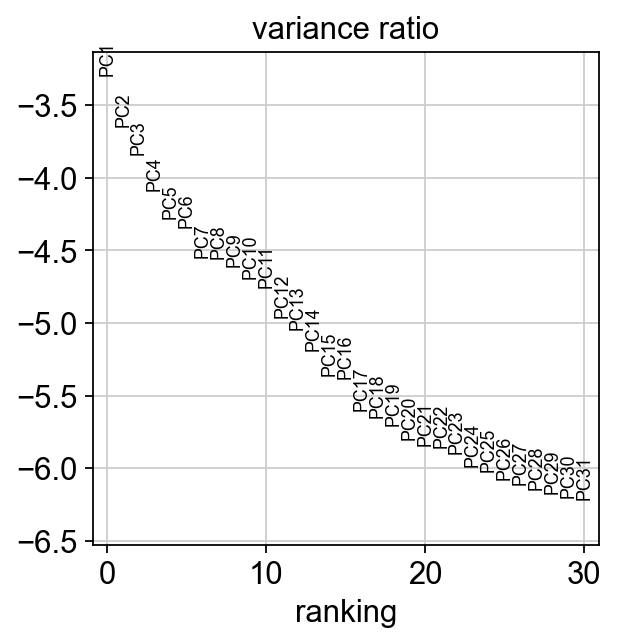

In [281]:
adata_qc.var['highly_variable'].fillna(value=False, inplace=True) # fill NaNs with False so that subsetting to HVGs is possible
adata_qc.obsm['X_pca'] = bdata.obsm['X_pca'].copy()
adata_qc.uns['pca'] = bdata.uns['pca'].copy()
adata_qc.varm['PCs'] = np.zeros(shape=(adata_qc.n_vars, 50))
adata_qc.varm['PCs'][adata_qc.var['highly_variable']] = bdata.varm['PCs']
sc.pl.pca_variance_ratio(adata_qc, log=True, save='.pdf')

In [282]:
n_pcs = 25
sc.pp.neighbors(adata_qc, n_pcs = n_pcs)
sc.tl.umap(adata_qc)

In [283]:
adata_qc.write('all_processed.h5ad')

In [284]:
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,sample
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9,female,SC3,snRNA-seq,public,gw9
11.2gw,gw11,not_provided_2,11,male,SC3,snRNA-seq,public,gw11
14+3gw,gw14,F20240701,14,male,SC3,snRNA-seq,in-house,gw14
15gw,gw15,not_provided_3,15,female,SC3,scRNA-seq,public,gw15
16+4gw,gw16,F20241018,16,male,SC3,snRNA-seq,in-house,gw16
17+2gw,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house,gw17_1
17+3gw,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house,gw17_2
17gw,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public,gw17_3
18+3gw,gw18,F20220806,18,male,SC3,snRNA-seq,in-house,gw18


In [285]:
adata_qc

AnnData object with n_obs × n_vars = 101419 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'n_cells_b

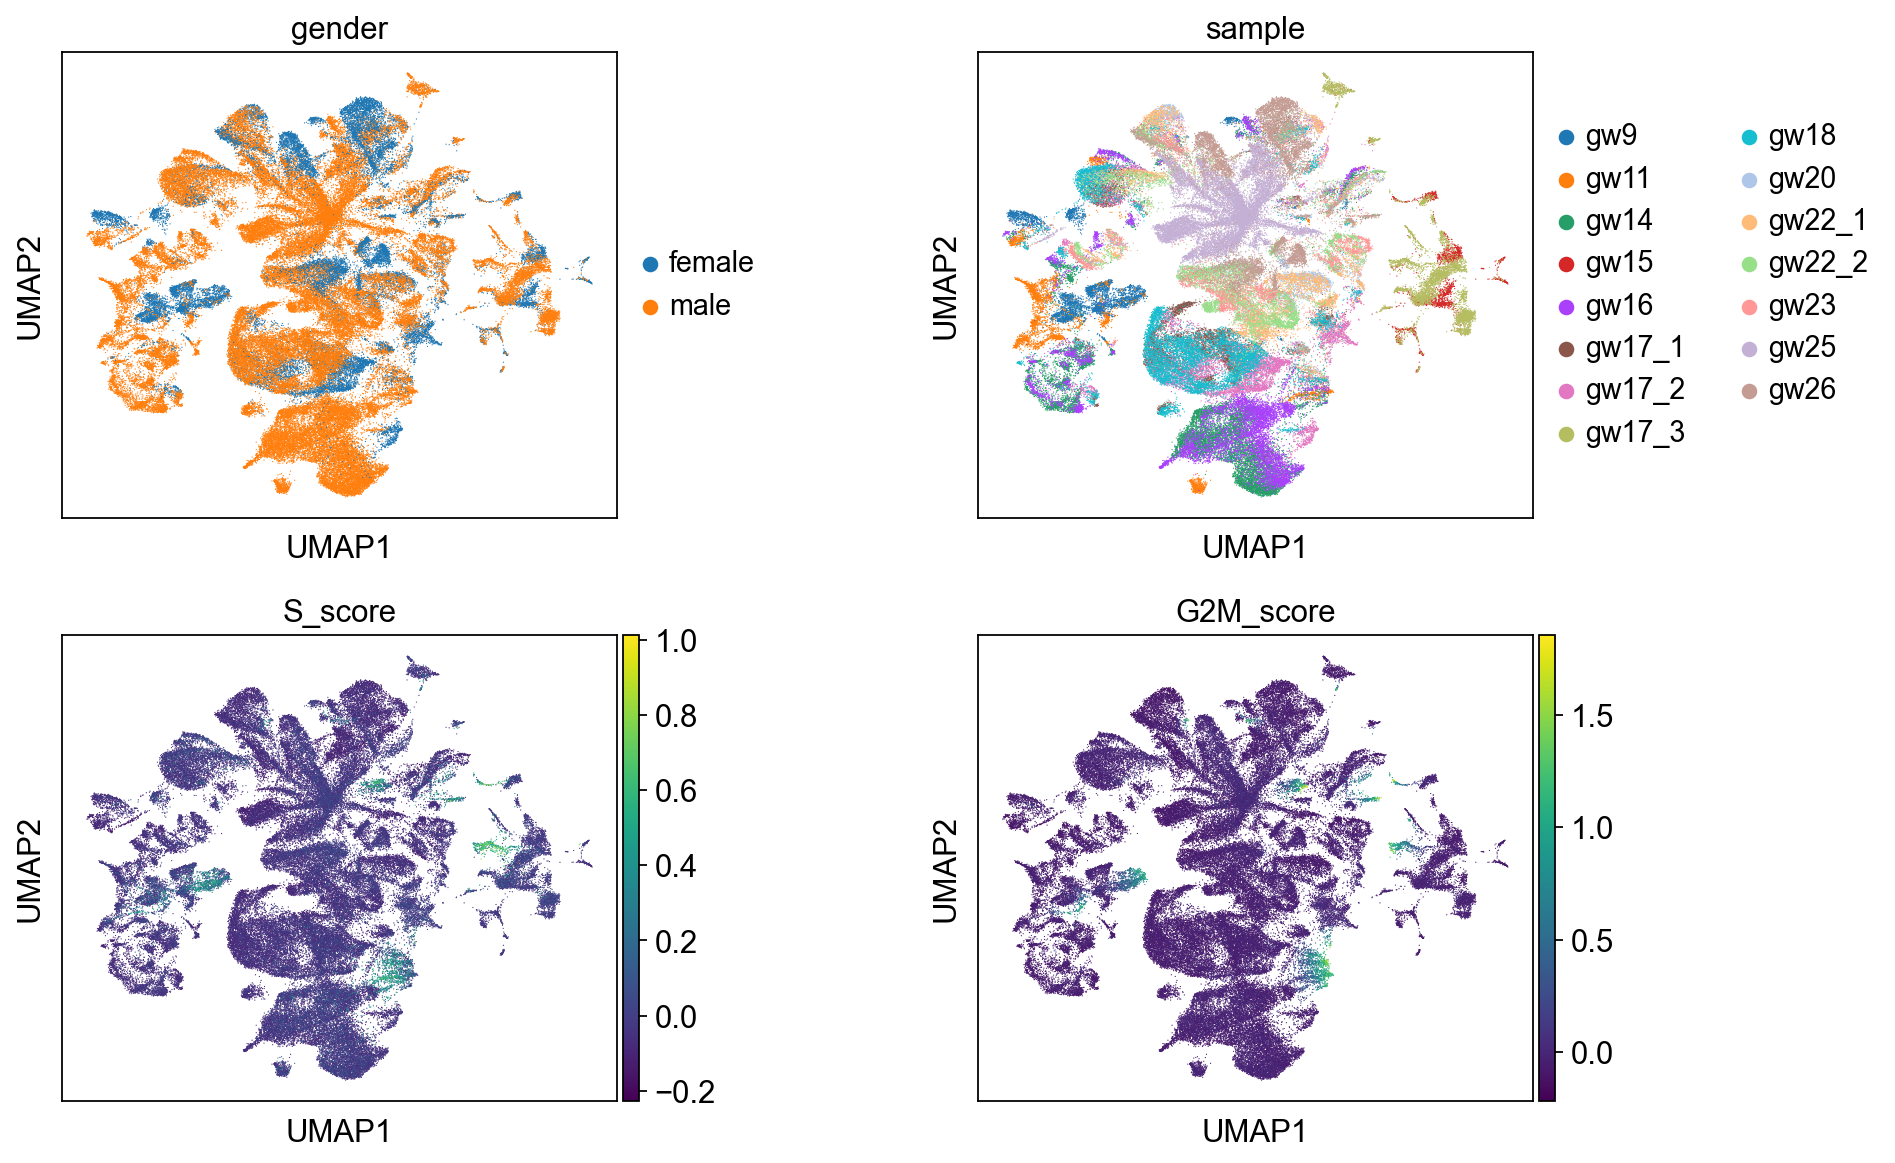

In [287]:
sc.pl.umap(adata_qc, color=[ 'gender', 'sample','S_score', 'G2M_score',], save='_predoublet.pdf', ncols = 2,wspace=0.5)

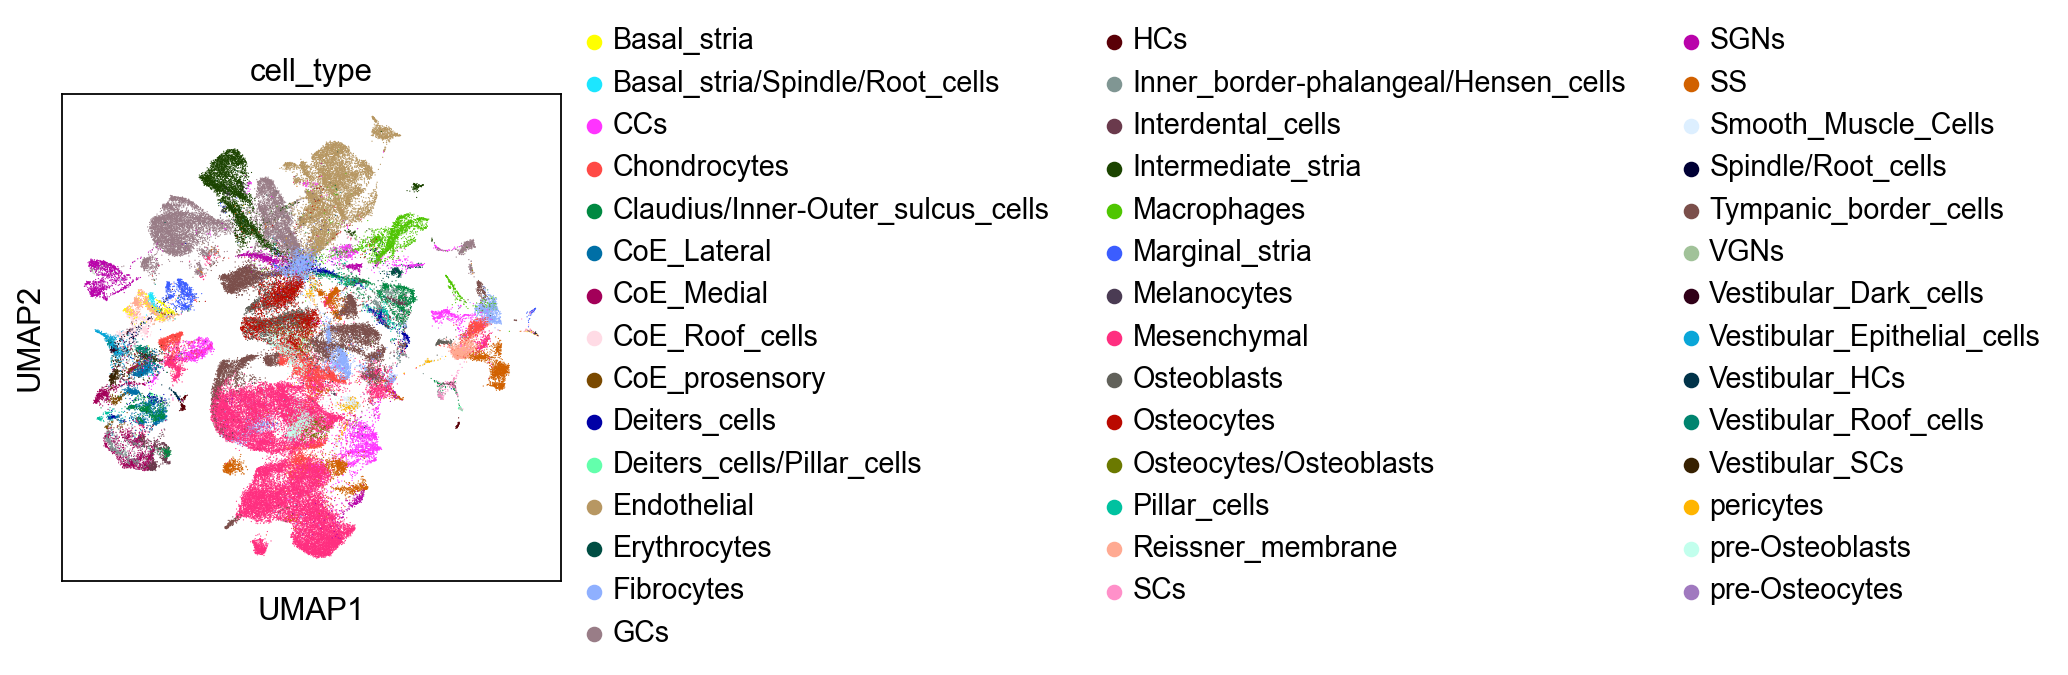

In [289]:
sc.pl.umap(adata_qc, color=[ 'cell_type',], save='_predoublet2.pdf', ncols = 2,wspace=0.5)

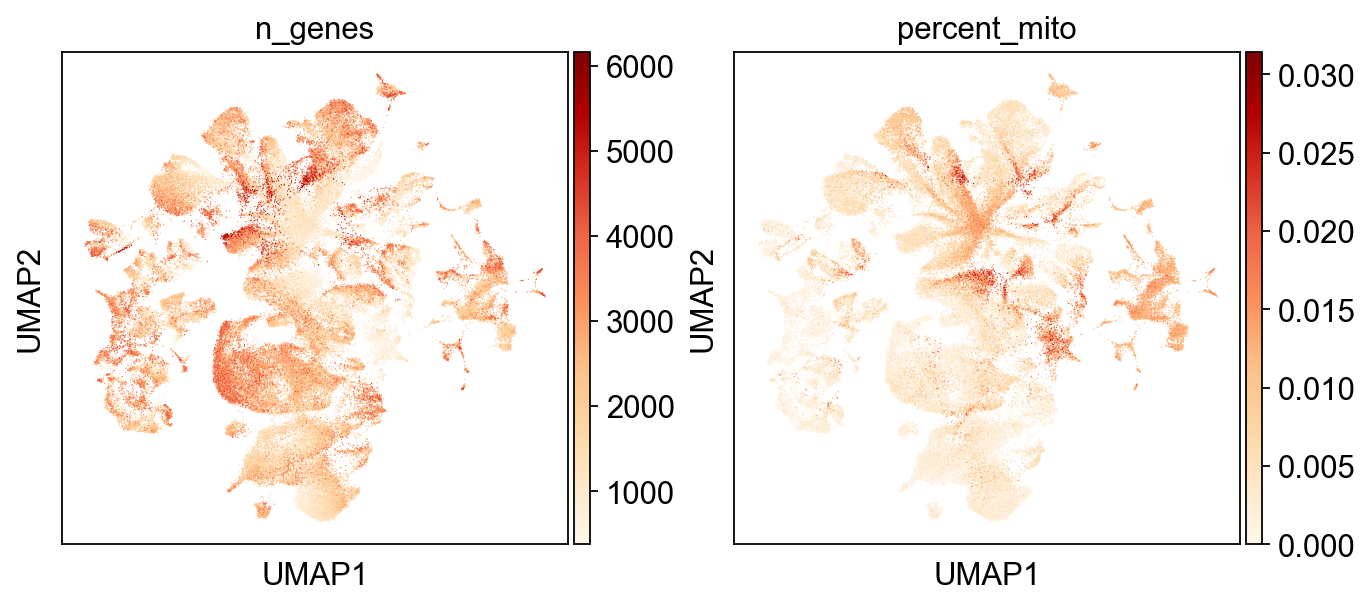

In [292]:
sc.pl.umap(adata_qc, color=['n_genes', 'percent_mito'], save='_predoublet_stats.pdf', ncols = 2, color_map='OrRd', use_raw=False)

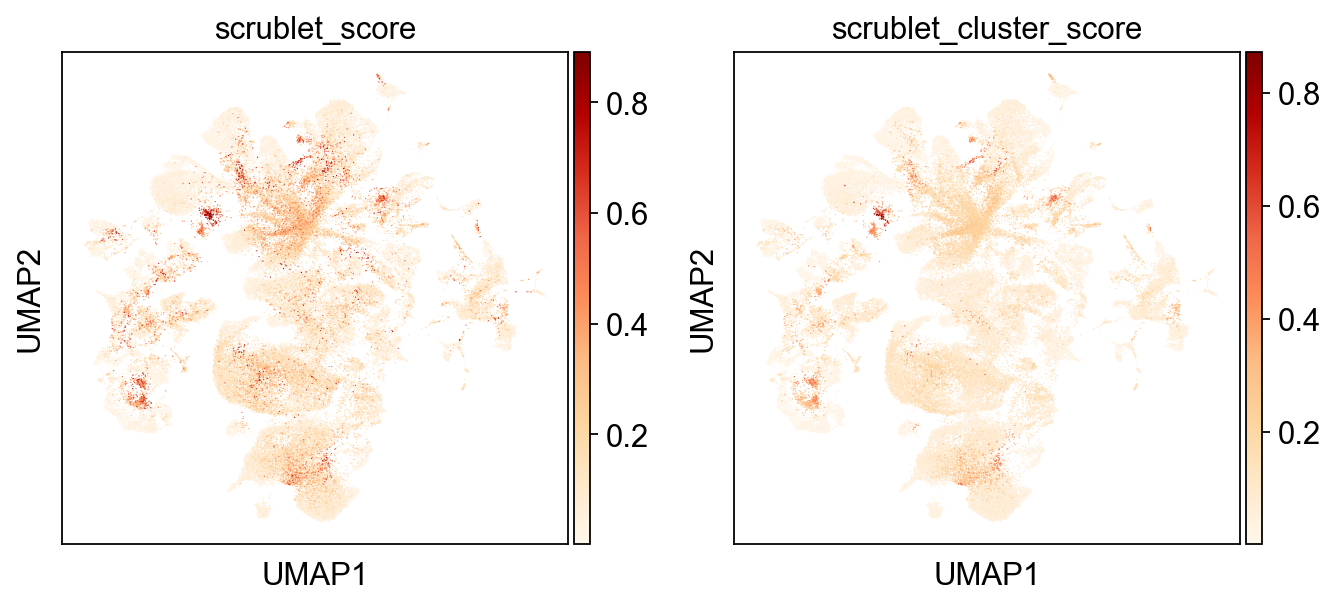

In [294]:
sc.pl.umap(adata_qc, color=['scrublet_score', 'scrublet_cluster_score'], color_map='OrRd', save='_predoublet_stats2.pdf',)

In [295]:
adata_qc.obs['cell_type'].value_counts()

cell_type
Mesenchymal                             27173
GCs                                      9492
Endothelial                              8573
Tympanic_border_cells                    8352
Fibrocytes                               4506
Chondrocytes                             4378
Intermediate_stria                       4301
Osteocytes                               3891
SS                                       3361
CCs                                      3354
Macrophages                              2096
SGNs                                     2067
Osteoblasts                              1987
Claudius/Inner-Outer_sulcus_cells        1894
CoE_Medial                               1760
CoE_Lateral                              1739
pre-Osteoblasts                          1373
Reissner_membrane                        1263
Interdental_cells                         981
Marginal_stria                            894
Inner_border-phalangeal/Hensen_cells      856
Osteocytes/Osteoblasts  

In [296]:
adata_hc=adata_qc[adata_qc.obs['cell_type']=='HCs']
adata_hc

View of AnnData object with n_obs × n_vars = 207 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_counts-1', 'mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'highly_variable-1', 'means-1', 'dispersions-1', 'dispersions_norm-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'n_ce

In [298]:
adata_hc.obs['sample'].value_counts()

sample
gw14      87
gw16      33
gw23      31
gw17_3    30
gw15      17
gw25       9
Name: count, dtype: int64